In [2]:
import numpy as np
import matplotlib.pyplot as plt


In [3]:
np.random.seed(42)

# Create 50 random x values
X = 2 * np.random.rand(50, 1)

# True parameters
true_slope = 3
true_intercept = 4

# Add Gaussian noise
y = true_slope * X + true_intercept + np.random.randn(50, 1)


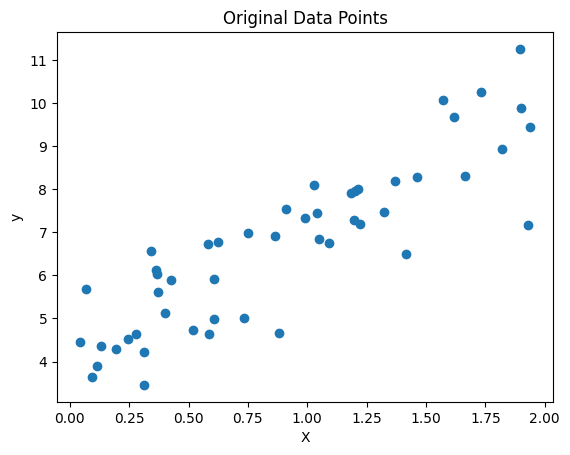

In [4]:
plt.scatter(X, y)
plt.title("Original Data Points")
plt.xlabel("X")
plt.ylabel("y")
plt.show()


In [5]:
# Add column of 1s for bias
X_b = np.c_[np.ones((50, 1)), X]

print("First 5 rows of X_b:")
print(X_b[:5])


First 5 rows of X_b:
[[1.         0.74908024]
 [1.         1.90142861]
 [1.         1.46398788]
 [1.         1.19731697]
 [1.         0.31203728]]


In [6]:
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

print("Learned Parameters:")
print("Intercept:", theta_best[0][0])
print("Slope:", theta_best[1][0])


Learned Parameters:
Intercept: 4.096689274468887
Slope: 2.8882830019265526


In [7]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]

y_predict = X_new_b.dot(theta_best)

print(y_predict)


[[4.09668927]
 [9.87325528]]


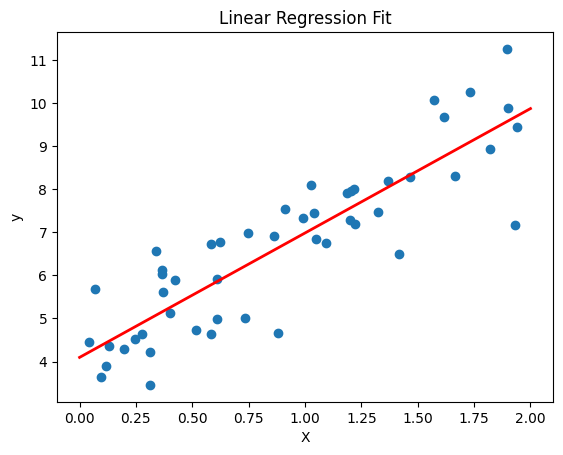

In [8]:
plt.scatter(X, y)
plt.plot(X_new, y_predict, "r-", linewidth=2)
plt.title("Linear Regression Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.show()


In [9]:
# Define Mean Squared Error function
def compute_mse(X_b, y, theta):
    predictions = X_b.dot(theta)
    errors = predictions - y
    mse = np.mean(errors ** 2)
    return mse

mse_value = compute_mse(X_b, y, theta_best)

print("Mean Squared Error:", mse_value)


Mean Squared Error: 0.8230711437486875


In [10]:
# Try wrong parameters
theta_wrong = np.array([[0], [0]])

mse_wrong = compute_mse(X_b, y, theta_wrong)

print("MSE with wrong parameters:", mse_wrong)


MSE with wrong parameters: 48.07567853754255


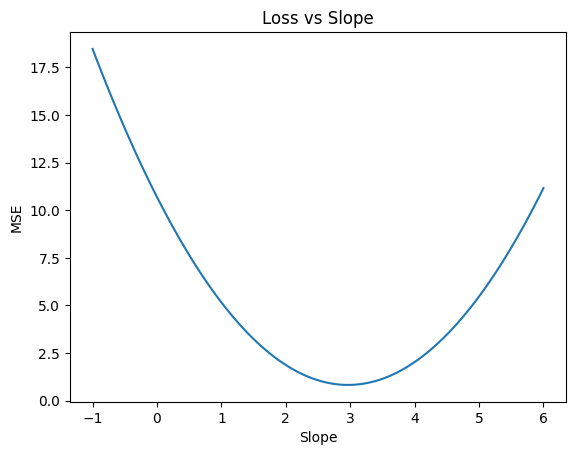

In [11]:
slopes = np.linspace(-1, 6, 100)
mse_values = []

for m in slopes:
    theta_temp = np.array([[4], [m]])  # Fix intercept at 4
    mse_values.append(compute_mse(X_b, y, theta_temp))

plt.plot(slopes, mse_values)
plt.title("Loss vs Slope")
plt.xlabel("Slope")
plt.ylabel("MSE")
plt.show()


In [12]:
from mpl_toolkits.mplot3d import Axes3D

# Create range of intercepts and slopes
intercepts = np.linspace(0, 8, 100)
slopes = np.linspace(-1, 6, 100)

# Create meshgrid
B, M = np.meshgrid(intercepts, slopes)

loss_surface = np.zeros(B.shape)

# Compute loss for each (b, m)
for i in range(len(intercepts)):
    for j in range(len(slopes)):
        theta_temp = np.array([[B[j, i]], [M[j, i]]])
        loss_surface[j, i] = compute_mse(X_b, y, theta_temp)


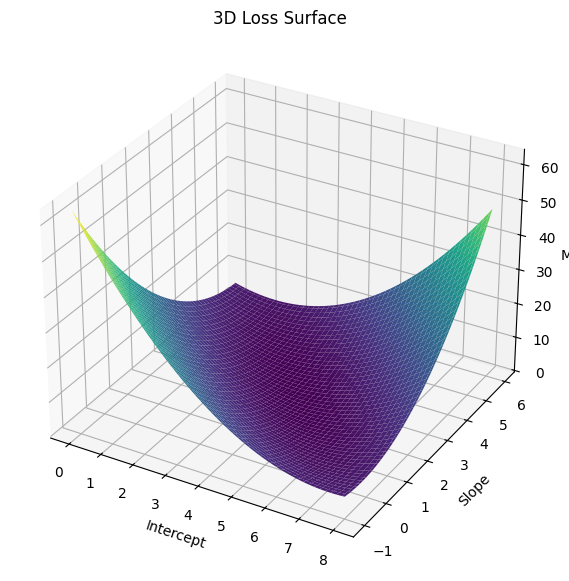

In [13]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(B, M, loss_surface, cmap='viridis')

ax.set_xlabel("Intercept")
ax.set_ylabel("Slope")
ax.set_zlabel("MSE")

plt.title("3D Loss Surface")
plt.show()


   Output (Cups/day)  Fixed Cost (FC)  Variable Cost per Cup (VC)  \
0                100             1000                           7   
1                200             1000                           7   
2                300             1000                           7   
3                400             1000                           7   
4                500             1000                           7   
5                600             1000                           7   

   Total Cost (TC)  Average Cost (AC)  
0             1700          17.000000  
1             2400          12.000000  
2             3100          10.333333  
3             3800           9.500000  
4             4500           9.000000  
5             5200           8.666667  


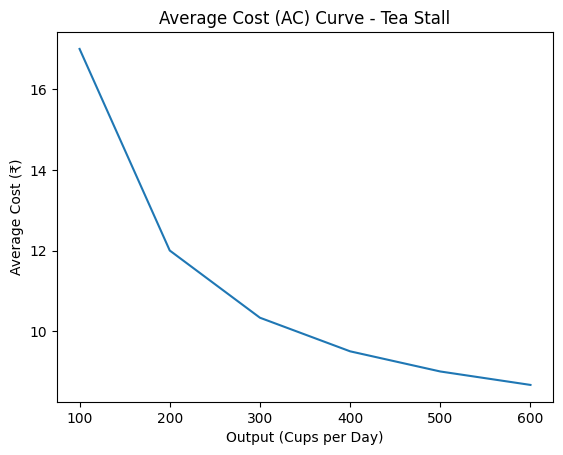

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Fixed and Variable Cost
FC = 1000
VC = 7

# Output levels (cups per day)
output = np.array([100, 200, 300, 400, 500, 600])

# Calculations
TC = FC + (VC * output)
AC = TC / output

# Create DataFrame (for table display)
data = pd.DataFrame({
    "Output (Cups/day)": output,
    "Fixed Cost (FC)": FC,
    "Variable Cost per Cup (VC)": VC,
    "Total Cost (TC)": TC,
    "Average Cost (AC)": AC
})

print(data)

# Plot Average Cost Curve
plt.figure()
plt.plot(output, AC)
plt.title("Average Cost (AC) Curve - Tea Stall")
plt.xlabel("Output (Cups per Day)")
plt.ylabel("Average Cost (₹)")
plt.show()

In [3]:
import pandas as pd

# ----------------------------
# Assumed Cost Data
# ----------------------------

fixed_cost = 1000          # Fixed Cost per day (₹)
variable_cost = 7          # Variable Cost per cup (₹)

# Output levels (cups sold per day)
output_levels = [100, 200, 300, 400, 500, 600]

# ----------------------------
# Calculations
# ----------------------------

data = []

for output in output_levels:
    total_cost = fixed_cost + (variable_cost * output)
    average_cost = total_cost / output
    
    data.append([
        output,
        fixed_cost,
        variable_cost,
        total_cost,
        round(average_cost, 2)
    ])

# Create DataFrame
df = pd.DataFrame(data, columns=[
    "Output (Cups per Day)",
    "Fixed Cost (₹)",
    "Variable Cost per Cup (₹)",
    "Total Cost (₹)",
    "Average Cost (₹)"
])

# Display Table
print(df)

   Output (Cups per Day)  Fixed Cost (₹)  Variable Cost per Cup (₹)  \
0                    100            1000                          7   
1                    200            1000                          7   
2                    300            1000                          7   
3                    400            1000                          7   
4                    500            1000                          7   
5                    600            1000                          7   

   Total Cost (₹)  Average Cost (₹)  
0            1700             17.00  
1            2400             12.00  
2            3100             10.33  
3            3800              9.50  
4            4500              9.00  
5            5200              8.67  


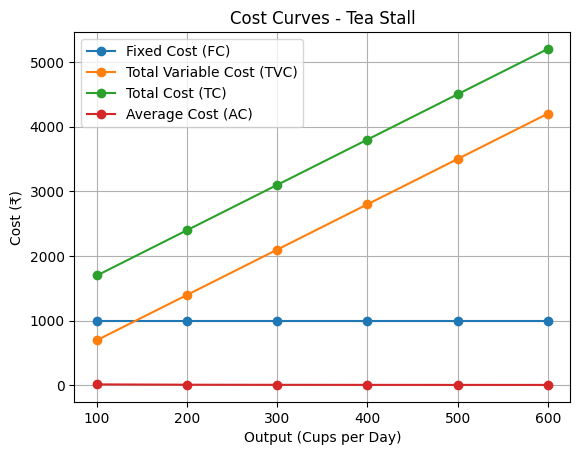

In [4]:
import matplotlib.pyplot as plt

# Given data
output = [100, 200, 300, 400, 500, 600]
fixed_cost = 1000
variable_cost_per_unit = 7

# Calculations
FC = [fixed_cost for _ in output]
TVC = [variable_cost_per_unit * q for q in output]
TC = [fixed_cost + variable_cost_per_unit * q for q in output]
AC = [tc / q for tc, q in zip(TC, output)]

# Plotting
plt.figure()

plt.plot(output, FC, marker='o')
plt.plot(output, TVC, marker='o')
plt.plot(output, TC, marker='o')
plt.plot(output, AC, marker='o')

plt.title("Cost Curves - Tea Stall")
plt.xlabel("Output (Cups per Day)")
plt.ylabel("Cost (₹)")

plt.legend(["Fixed Cost (FC)", 
            "Total Variable Cost (TVC)", 
            "Total Cost (TC)", 
            "Average Cost (AC)"])

plt.grid(True)

plt.show()

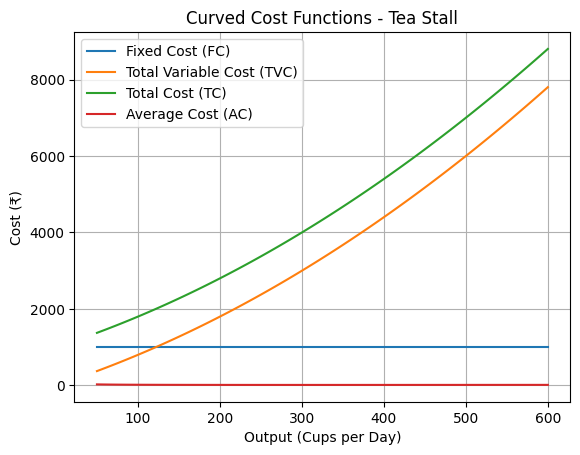

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Output range (more points for smooth curve)
output = np.linspace(50, 600, 100)

fixed_cost = 1000

# Variable cost increases slightly due to inefficiency
TVC = 7 * output + 0.01 * output**2

TC = fixed_cost + TVC
AC = TC / output
FC = [fixed_cost for _ in output]

plt.figure()

plt.plot(output, FC)
plt.plot(output, TVC)
plt.plot(output, TC)
plt.plot(output, AC)

plt.title("Curved Cost Functions - Tea Stall")
plt.xlabel("Output (Cups per Day)")
plt.ylabel("Cost (₹)")

plt.legend(["Fixed Cost (FC)",
            "Total Variable Cost (TVC)",
            "Total Cost (TC)",
            "Average Cost (AC)"])

plt.grid(True)
plt.show()

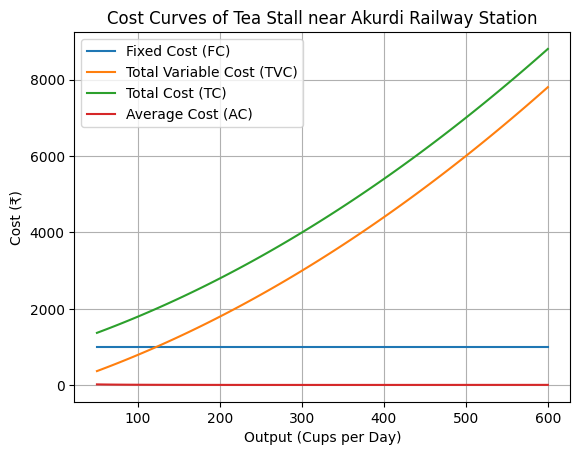

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Cost Assumptions
# ----------------------------

fixed_cost = 1000

# Smooth output values for proper curves
output = np.linspace(50, 600, 100)

# Variable cost increases slightly (to show realistic curvature)
TVC = 7 * output + 0.01 * output**2

TC = fixed_cost + TVC
AC = TC / output
FC = np.full_like(output, fixed_cost)

# ----------------------------
# Plot Graph
# ----------------------------

plt.figure()

plt.plot(output, FC)
plt.plot(output, TVC)
plt.plot(output, TC)
plt.plot(output, AC)

plt.title("Cost Curves of Tea Stall near Akurdi Railway Station")
plt.xlabel("Output (Cups per Day)")
plt.ylabel("Cost (₹)")

plt.legend([
    "Fixed Cost (FC)",
    "Total Variable Cost (TVC)",
    "Total Cost (TC)",
    "Average Cost (AC)"
])

plt.grid(True)

plt.show()

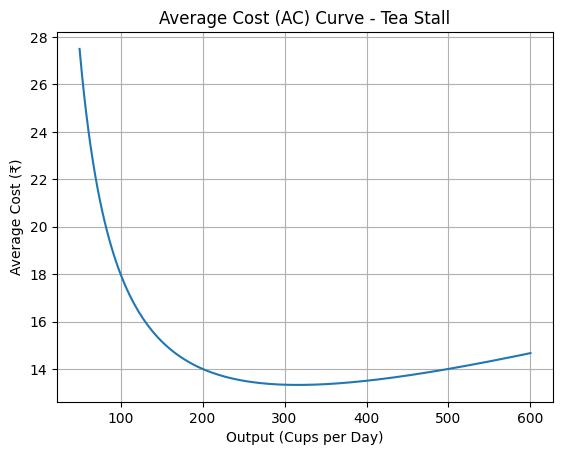

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Fixed Cost
fixed_cost = 1000

# Smooth output values for proper curve
output = np.linspace(50, 600, 200)

# Variable cost with slight increase to show realistic U-shape
total_cost = fixed_cost + (7 * output) + (0.01 * output**2)

# Average Cost
average_cost = total_cost / output

# Plot AC Curve
plt.figure()

plt.plot(output, average_cost)

plt.title("Average Cost (AC) Curve - Tea Stall")
plt.xlabel("Output (Cups per Day)")
plt.ylabel("Average Cost (₹)")

plt.grid(True)

plt.show()

In [4]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


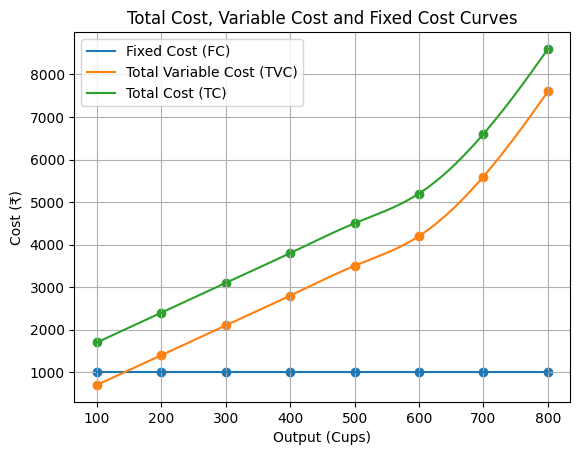

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# Data from your table
output = np.array([100, 200, 300, 400, 500, 600, 700, 800])

fixed_cost = np.array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000])
total_variable_cost = np.array([700, 1400, 2100, 2800, 3500, 4200, 5600, 7600])
total_cost = np.array([1700, 2400, 3100, 3800, 4500, 5200, 6600, 8600])

# Create smooth curve using spline interpolation
output_smooth = np.linspace(output.min(), output.max(), 300)

tvc_spline = make_interp_spline(output, total_variable_cost)
tc_spline = make_interp_spline(output, total_cost)
fc_spline = make_interp_spline(output, fixed_cost)

tvc_smooth = tvc_spline(output_smooth)
tc_smooth = tc_spline(output_smooth)
fc_smooth = fc_spline(output_smooth)

# Plot
plt.figure()

plt.plot(output_smooth, fc_smooth)
plt.plot(output_smooth, tvc_smooth)
plt.plot(output_smooth, tc_smooth)

plt.scatter(output, fixed_cost)
plt.scatter(output, total_variable_cost)
plt.scatter(output, total_cost)

plt.title("Total Cost, Variable Cost and Fixed Cost Curves")
plt.xlabel("Output (Cups)")
plt.ylabel("Cost (₹)")

plt.legend(["Fixed Cost (FC)",
            "Total Variable Cost (TVC)",
            "Total Cost (TC)"])

plt.grid(True)
plt.show()

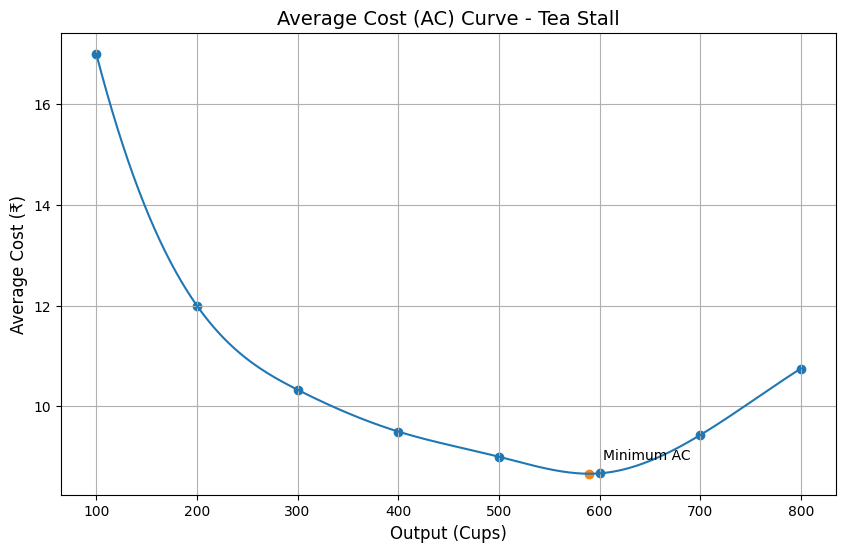

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# -------------------------
# Data from your table
# -------------------------

output = np.array([100, 200, 300, 400, 500, 600, 700, 800])
average_cost = np.array([17, 12, 10.33, 9.5, 9, 8.67, 9.43, 10.75])

# -------------------------
# Create smooth curve using Cubic Spline
# -------------------------

output_smooth = np.linspace(output.min(), output.max(), 400)

spline = make_interp_spline(output, average_cost, k=3)
ac_smooth = spline(output_smooth)

# -------------------------
# Find minimum AC point
# -------------------------

min_index = np.argmin(ac_smooth)
min_output = output_smooth[min_index]
min_ac = ac_smooth[min_index]

# -------------------------
# Plot Graph
# -------------------------

plt.figure(figsize=(10, 6))

plt.plot(output_smooth, ac_smooth)
plt.scatter(output, average_cost)

plt.scatter(min_output, min_ac)

plt.title("Average Cost (AC) Curve - Tea Stall", fontsize=14)
plt.xlabel("Output (Cups)", fontsize=12)
plt.ylabel("Average Cost (₹)", fontsize=12)

plt.grid(True)

plt.annotate(
    "Minimum AC",
    (min_output, min_ac),
    textcoords="offset points",
    xytext=(10,10)
)

plt.show()

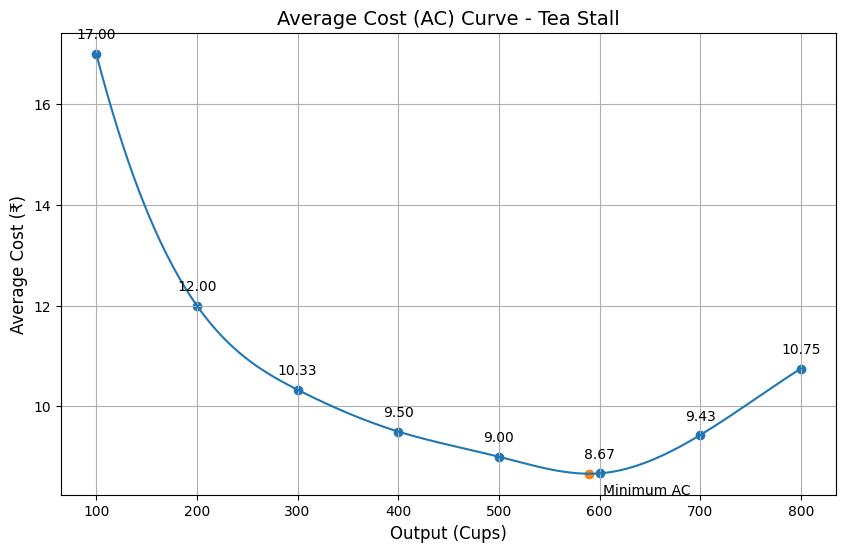

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# -------------------------
# Data from your table
# -------------------------

output = np.array([100, 200, 300, 400, 500, 600, 700, 800])
average_cost = np.array([17, 12, 10.33, 9.5, 9, 8.67, 9.43, 10.75])

# -------------------------
# Smooth curve using Cubic Spline
# -------------------------

output_smooth = np.linspace(output.min(), output.max(), 400)
spline = make_interp_spline(output, average_cost, k=3)
ac_smooth = spline(output_smooth)

# -------------------------
# Find minimum AC point
# -------------------------

min_index = np.argmin(ac_smooth)
min_output = output_smooth[min_index]
min_ac = ac_smooth[min_index]

# -------------------------
# Plot Graph
# -------------------------

plt.figure(figsize=(10, 6))

# Smooth AC curve
plt.plot(output_smooth, ac_smooth)

# Actual data points
plt.scatter(output, average_cost)

# Label each data point
for x, y in zip(output, average_cost):
    plt.text(x, y + 0.3, f"{y:.2f}", ha='center')

# Highlight minimum AC
plt.scatter(min_output, min_ac)
plt.annotate("Minimum AC",
             (min_output, min_ac),
             textcoords="offset points",
             xytext=(10, -15))

plt.title("Average Cost (AC) Curve - Tea Stall", fontsize=14)
plt.xlabel("Output (Cups)", fontsize=12)
plt.ylabel("Average Cost (₹)", fontsize=12)

plt.grid(True)
plt.show()

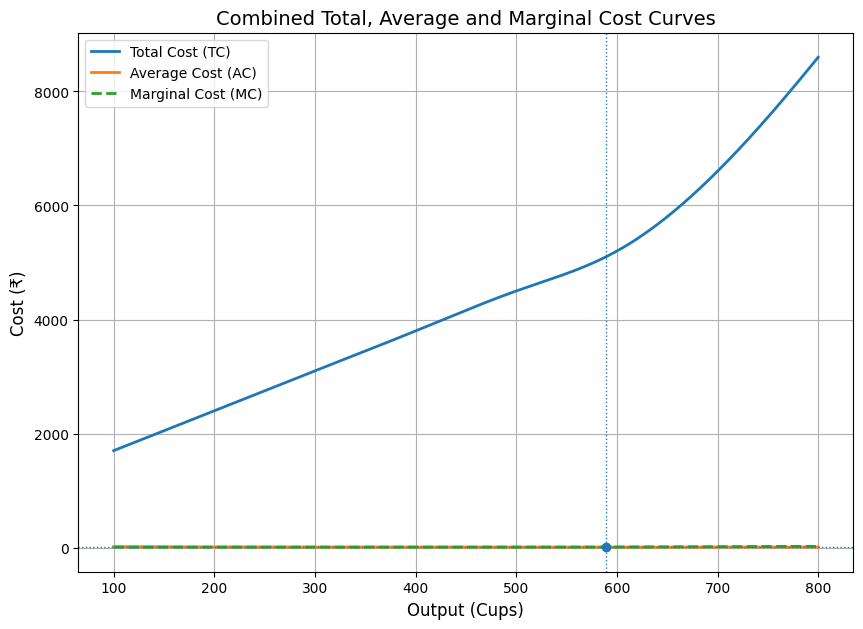

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# -----------------------------
# Original Data from Your Table
# -----------------------------

output = np.array([100, 200, 300, 400, 500, 600, 700, 800])
TC = np.array([1700, 2400, 3100, 3800, 4500, 5200, 6600, 8600])
AC = np.array([17, 12, 10.33, 9.5, 9, 8.67, 9.43, 10.75])

# -----------------------------
# Calculate Marginal Cost (MC)
# MC = Change in TC / Change in Output
# -----------------------------

MC = np.diff(TC) / np.diff(output)
MC_output = (output[:-1] + output[1:]) / 2

# -----------------------------
# Smooth Curves using Cubic Spline
# -----------------------------

output_smooth = np.linspace(output.min(), output.max(), 500)

tc_spline = make_interp_spline(output, TC, k=3)
ac_spline = make_interp_spline(output, AC, k=3)
mc_spline = make_interp_spline(MC_output, MC, k=2)

TC_smooth = tc_spline(output_smooth)
AC_smooth = ac_spline(output_smooth)
MC_smooth = mc_spline(output_smooth)

# -----------------------------
# Find Minimum AC Point
# -----------------------------

min_index = np.argmin(AC_smooth)
min_output = output_smooth[min_index]
min_ac = AC_smooth[min_index]

# -----------------------------
# Plot Textbook-Style Diagram
# -----------------------------

plt.figure(figsize=(10, 7))

plt.plot(output_smooth, TC_smooth, linewidth=2, label="Total Cost (TC)")
plt.plot(output_smooth, AC_smooth, linewidth=2, label="Average Cost (AC)")
plt.plot(output_smooth, MC_smooth, linewidth=2, linestyle="--", label="Marginal Cost (MC)")

# Highlight minimum AC point
plt.scatter(min_output, min_ac, zorder=5)
plt.axvline(x=min_output, linestyle=":", linewidth=1)
plt.axhline(y=min_ac, linestyle=":", linewidth=1)

plt.title("Combined Total, Average and Marginal Cost Curves", fontsize=14)
plt.xlabel("Output (Cups)", fontsize=12)
plt.ylabel("Cost (₹)", fontsize=12)

plt.legend()
plt.grid(True)

# -----------------------------
# Export High-Resolution PNG
# -----------------------------

plt.savefig("Combined_Cost_Curves_300DPI.png", dpi=300, bbox_inches='tight')

plt.show()

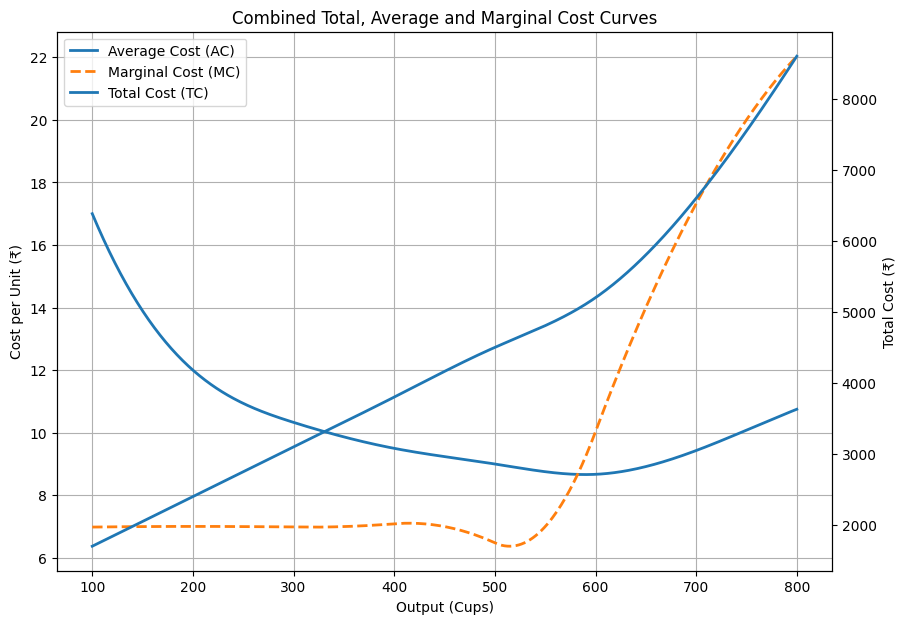

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# -----------------------------
# Data
# -----------------------------

output = np.array([100, 200, 300, 400, 500, 600, 700, 800])
TC = np.array([1700, 2400, 3100, 3800, 4500, 5200, 6600, 8600])
AC = np.array([17, 12, 10.33, 9.5, 9, 8.67, 9.43, 10.75])

# Marginal Cost
MC = np.diff(TC) / np.diff(output)
MC_output = (output[:-1] + output[1:]) / 2

# Smooth Curves
output_smooth = np.linspace(output.min(), output.max(), 500)

tc_spline = make_interp_spline(output, TC, k=3)
ac_spline = make_interp_spline(output, AC, k=3)
mc_spline = make_interp_spline(MC_output, MC, k=2)

TC_smooth = tc_spline(output_smooth)
AC_smooth = ac_spline(output_smooth)
MC_smooth = mc_spline(output_smooth)

# -----------------------------
# Plot
# -----------------------------

fig, ax1 = plt.subplots(figsize=(10,7))

# Left axis (AC & MC)
ax1.plot(output_smooth, AC_smooth, linewidth=2, label="Average Cost (AC)")
ax1.plot(output_smooth, MC_smooth, linestyle='--', linewidth=2, label="Marginal Cost (MC)")
ax1.set_xlabel("Output (Cups)")
ax1.set_ylabel("Cost per Unit (₹)")
ax1.grid(True)

# Right axis (TC)
ax2 = ax1.twinx()
ax2.plot(output_smooth, TC_smooth, linewidth=2, label="Total Cost (TC)")
ax2.set_ylabel("Total Cost (₹)")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Combined Total, Average and Marginal Cost Curves")

# Export high resolution
plt.savefig("Textbook_Combined_Cost_Curves.png", dpi=300, bbox_inches='tight')

plt.show()

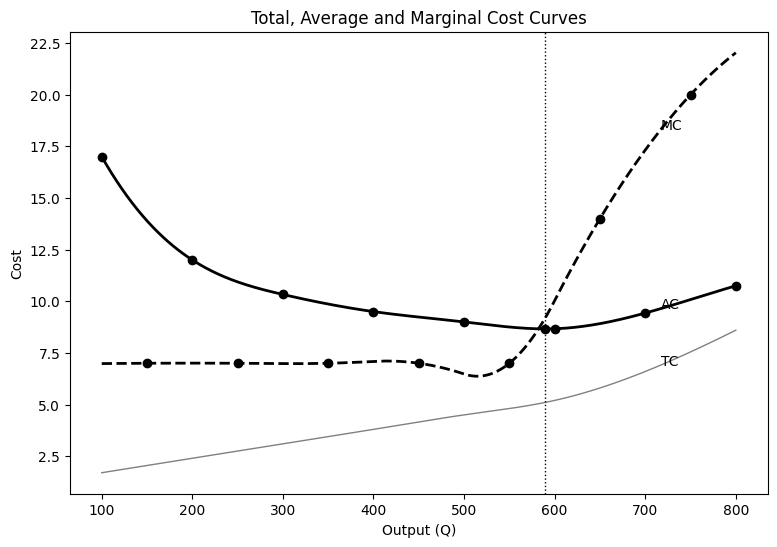

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# -----------------------------
# Data from your table
# -----------------------------

Q = np.array([100, 200, 300, 400, 500, 600, 700, 800])
TC = np.array([1700, 2400, 3100, 3800, 4500, 5200, 6600, 8600])
AC = np.array([17, 12, 10.33, 9.5, 9, 8.67, 9.43, 10.75])

# Marginal Cost
MC = np.diff(TC) / np.diff(Q)
Q_mc = (Q[:-1] + Q[1:]) / 2

# -----------------------------
# Smooth Curves
# -----------------------------

Q_smooth = np.linspace(Q.min(), Q.max(), 500)

ac_spline = make_interp_spline(Q, AC, k=3)
mc_spline = make_interp_spline(Q_mc, MC, k=2)
tc_spline = make_interp_spline(Q, TC, k=3)

AC_smooth = ac_spline(Q_smooth)
MC_smooth = mc_spline(Q_smooth)
TC_smooth = tc_spline(Q_smooth)

# -----------------------------
# Plot (Textbook Style)
# -----------------------------

plt.figure(figsize=(9,6))

# Per-unit cost curves
plt.plot(Q_smooth, AC_smooth, color='black', linewidth=2)
plt.plot(Q_smooth, MC_smooth, color='black', linestyle='--', linewidth=2)

# Total cost (lighter style)
plt.plot(Q_smooth, TC_smooth/1000, color='gray', linewidth=1)

# Plot actual data points
plt.scatter(Q, AC, color='black')
plt.scatter(Q_mc, MC, color='black')

# Find minimum AC
min_index = np.argmin(AC_smooth)
Q_min = Q_smooth[min_index]
AC_min = AC_smooth[min_index]

plt.scatter(Q_min, AC_min, color='black')
plt.axvline(Q_min, linestyle=':', color='black', linewidth=1)

# Labels (Textbook formatting)
plt.xlabel("Output (Q)")
plt.ylabel("Cost")

plt.title("Total, Average and Marginal Cost Curves")

plt.text(Q_smooth[-60], AC_smooth[-60], "AC")
plt.text(Q_smooth[-60], MC_smooth[-60], "MC")
plt.text(Q_smooth[-60], TC_smooth[-60]/1000, "TC")

plt.grid(False)

plt.savefig("Textbook_Cost_Curves_300DPI.png", dpi=300, bbox_inches='tight')

plt.show()

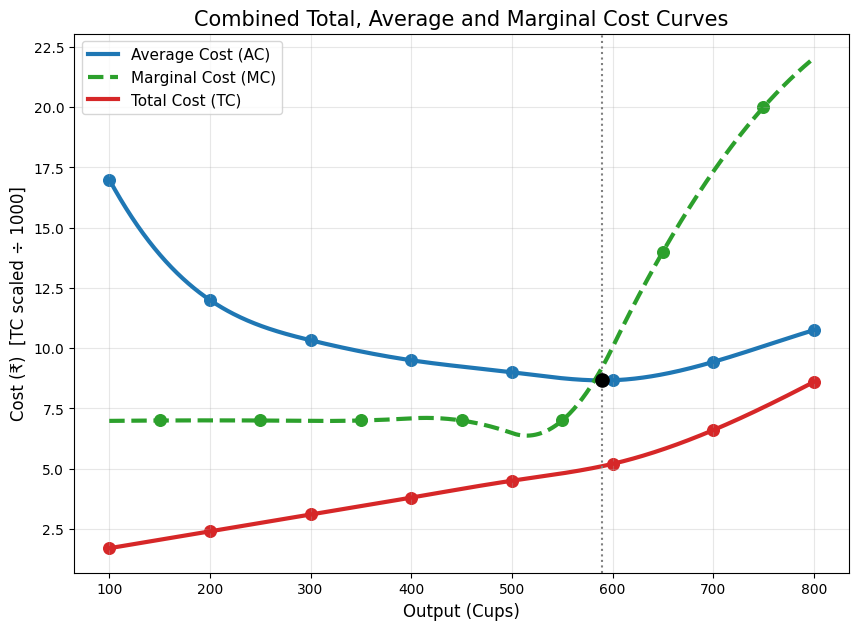

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# -----------------------------
# Data from your table
# -----------------------------

Q = np.array([100, 200, 300, 400, 500, 600, 700, 800])
TC = np.array([1700, 2400, 3100, 3800, 4500, 5200, 6600, 8600])
AC = np.array([17, 12, 10.33, 9.5, 9, 8.67, 9.43, 10.75])

# Marginal Cost calculation
MC = np.diff(TC) / np.diff(Q)
Q_mc = (Q[:-1] + Q[1:]) / 2

# -----------------------------
# Smooth Curves
# -----------------------------

Q_smooth = np.linspace(Q.min(), Q.max(), 500)

ac_spline = make_interp_spline(Q, AC, k=3)
mc_spline = make_interp_spline(Q_mc, MC, k=2)
tc_spline = make_interp_spline(Q, TC, k=3)

AC_smooth = ac_spline(Q_smooth)
MC_smooth = mc_spline(Q_smooth)
TC_smooth = tc_spline(Q_smooth)

# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(10, 7))

# Plot smooth curves
plt.plot(Q_smooth, AC_smooth, color="#1f77b4", linewidth=3, label="Average Cost (AC)")
plt.plot(Q_smooth, MC_smooth, color="#2ca02c", linestyle="--", linewidth=3, label="Marginal Cost (MC)")
plt.plot(Q_smooth, TC_smooth/1000, color="#d62728", linewidth=3, label="Total Cost (TC)")

# Plot actual data points
plt.scatter(Q, AC, color="#1f77b4", s=70)
plt.scatter(Q_mc, MC, color="#2ca02c", s=70)
plt.scatter(Q, TC/1000, color="#d62728", s=70)

# Highlight minimum AC
min_index = np.argmin(AC_smooth)
Q_min = Q_smooth[min_index]
AC_min = AC_smooth[min_index]

plt.scatter(Q_min, AC_min, color="black", s=90, zorder=5)
plt.axvline(Q_min, linestyle=":", color="gray")

# Labels
plt.title("Combined Total, Average and Marginal Cost Curves", fontsize=15)
plt.xlabel("Output (Cups)", fontsize=12)
plt.ylabel("Cost (₹)  [TC scaled ÷ 1000]", fontsize=12)

plt.legend(fontsize=11)
plt.grid(alpha=0.3)

# Export high resolution
plt.savefig("Best_Combined_Cost_Curves_300DPI.png", dpi=300, bbox_inches='tight')

plt.show()

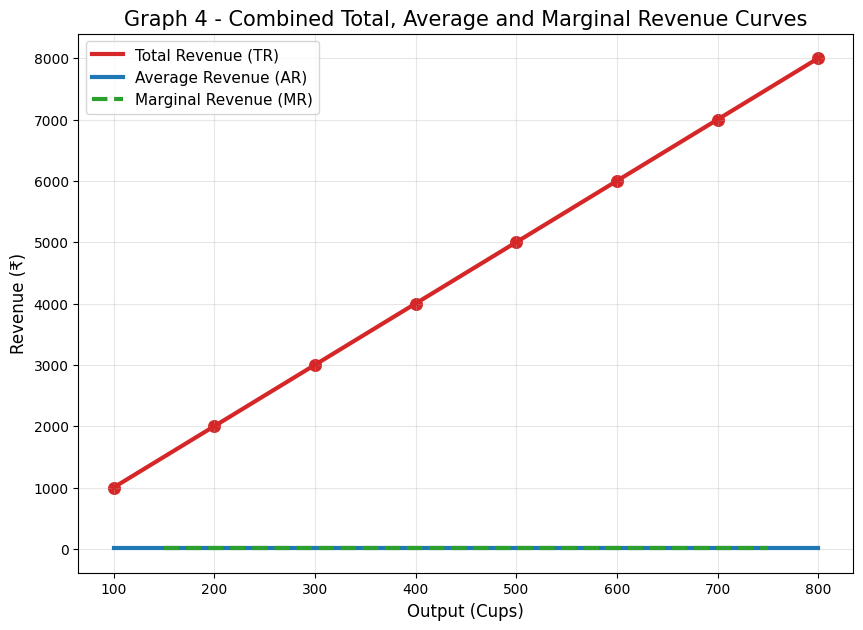

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# -----------------------------
# Given Data
# -----------------------------

Q = np.array([100, 200, 300, 400, 500, 600, 700, 800])
price = 10

# Revenue Calculations
TR = price * Q
AR = np.full_like(Q, price)
MR = np.full_like(Q[:-1], price)
Q_mr = (Q[:-1] + Q[1:]) / 2

# -----------------------------
# Smooth TR Curve
# -----------------------------

Q_smooth = np.linspace(Q.min(), Q.max(), 400)
tr_spline = make_interp_spline(Q, TR, k=2)
TR_smooth = tr_spline(Q_smooth)

# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(10, 7))

# TR curve
plt.plot(Q_smooth, TR_smooth, color="#d62728", linewidth=3, label="Total Revenue (TR)")
plt.scatter(Q, TR, color="#d62728", s=70)

# AR and MR lines
plt.plot(Q, AR, color="#1f77b4", linewidth=3, label="Average Revenue (AR)")
plt.plot(Q_mr, MR, color="#2ca02c", linestyle="--", linewidth=3, label="Marginal Revenue (MR)")

# Labels
plt.title("Graph 4 - Combined Total, Average and Marginal Revenue Curves", fontsize=15)
plt.xlabel("Output (Cups)", fontsize=12)
plt.ylabel("Revenue (₹)", fontsize=12)

plt.legend(fontsize=11)
plt.grid(alpha=0.3)

# Export High Resolution
plt.savefig("Graph4_Revenue_Curves_300DPI.png", dpi=300, bbox_inches='tight')

plt.show()

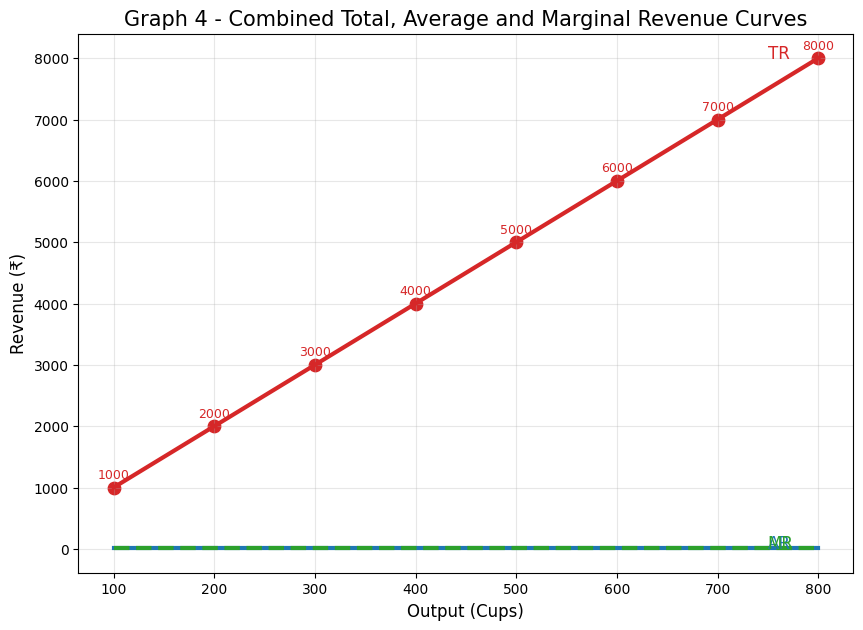

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# -----------------------------
# Data
# -----------------------------

Q = np.array([100, 200, 300, 400, 500, 600, 700, 800])
price = 10

TR = price * Q
AR = np.full_like(Q, price)
MR = np.full_like(Q, price)

# Smooth TR curve
Q_smooth = np.linspace(Q.min(), Q.max(), 400)
tr_spline = make_interp_spline(Q, TR, k=2)
TR_smooth = tr_spline(Q_smooth)

# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(10, 7))

# Total Revenue Curve
plt.plot(Q_smooth, TR_smooth, color="#d62728", linewidth=3)
plt.scatter(Q, TR, color="#d62728", s=80)

# Label TR curve
plt.text(750, TR[-1], "TR", fontsize=12, color="#d62728")

# Average Revenue Line
plt.plot(Q, AR, color="#1f77b4", linewidth=3)
plt.text(750, price+0.5, "AR", fontsize=12, color="#1f77b4")

# Marginal Revenue Line
plt.plot(Q, MR, color="#2ca02c", linestyle="--", linewidth=3)
plt.text(750, price-0.8, "MR", fontsize=12, color="#2ca02c")

# -----------------------------
# Number each TR point
# -----------------------------

for x, y in zip(Q, TR):
    plt.text(x, y + 150, f"{y}", ha='center', fontsize=9, color="#d62728")

# -----------------------------
# Formatting
# -----------------------------

plt.title("Graph 4 - Combined Total, Average and Marginal Revenue Curves", fontsize=15)
plt.xlabel("Output (Cups)", fontsize=12)
plt.ylabel("Revenue (₹)", fontsize=12)

plt.grid(alpha=0.3)




plt.show()

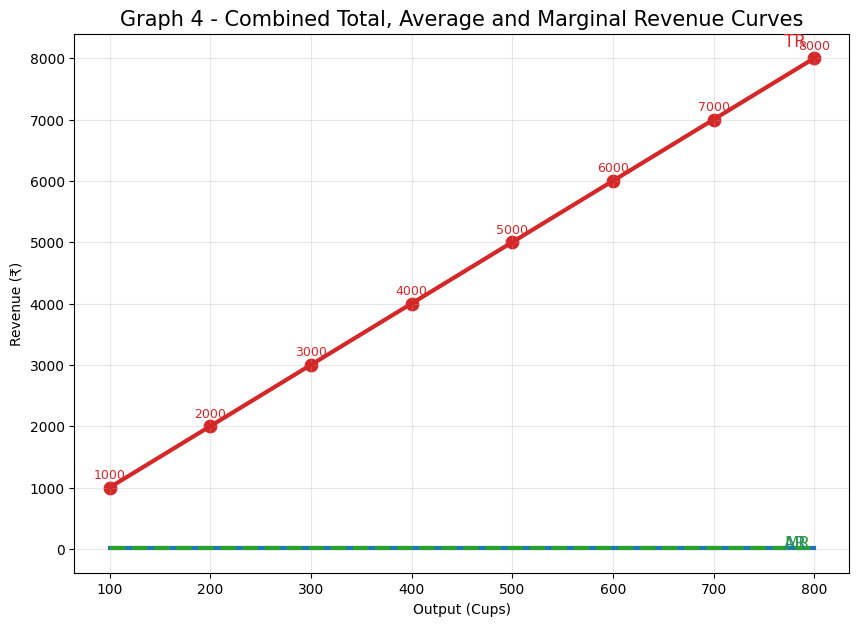

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# Data
Q = np.array([100, 200, 300, 400, 500, 600, 700, 800])
price = 10

TR = price * Q
AR = np.full_like(Q, price)
MR = np.full_like(Q, price)

# Smooth TR
Q_smooth = np.linspace(Q.min(), Q.max(), 400)
tr_spline = make_interp_spline(Q, TR, k=2)
TR_smooth = tr_spline(Q_smooth)

plt.figure(figsize=(10,7))

# TR
plt.plot(Q_smooth, TR_smooth, color="#d62728", linewidth=3)
plt.scatter(Q, TR, color="#d62728", s=80)
plt.text(770, TR[-1]+200, "TR", fontsize=12, color="#d62728")

# AR (slightly above line)
plt.plot(Q, AR, color="#1f77b4", linewidth=3)
plt.text(770, price+1, "AR", fontsize=12, color="#1f77b4")

# MR (slightly below line)
plt.plot(Q, MR, color="#2ca02c", linestyle="--", linewidth=3)
plt.text(770, price-1.2, "MR", fontsize=12, color="#2ca02c")

# Label TR points
for x, y in zip(Q, TR):
    plt.text(x, y + 150, f"{y}", ha='center', fontsize=9, color="#d62728")

plt.title("Graph 4 - Combined Total, Average and Marginal Revenue Curves", fontsize=15)
plt.xlabel("Output (Cups)")
plt.ylabel("Revenue (₹)")
plt.grid(alpha=0.3)

plt.savefig("Graph4_Revenue_Curves_Clean_300DPI.png", dpi=300, bbox_inches='tight')
plt.show()

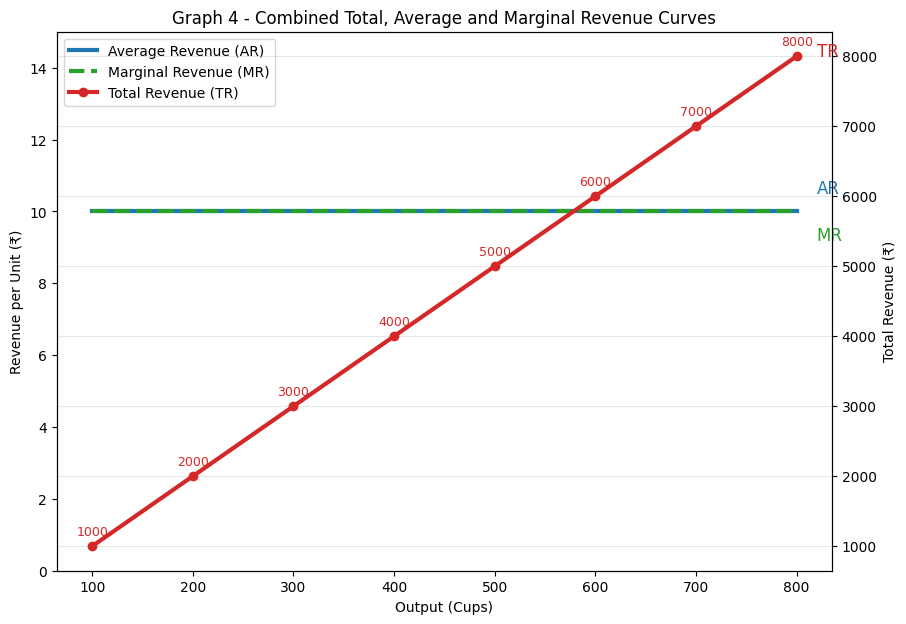

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Data
Q = np.array([100, 200, 300, 400, 500, 600, 700, 800])
price = 10

TR = price * Q
AR = np.full_like(Q, price)
MR = np.full_like(Q, price)

# Create figure
fig, ax1 = plt.subplots(figsize=(10,7))

# -----------------------------
# Left Axis (AR & MR)
# -----------------------------
ax1.plot(Q, AR, color="#1f77b4", linewidth=3, label="Average Revenue (AR)")
ax1.plot(Q, MR, color="#2ca02c", linestyle="--", linewidth=3, label="Marginal Revenue (MR)")
ax1.set_xlabel("Output (Cups)")
ax1.set_ylabel("Revenue per Unit (₹)")
ax1.set_ylim(0, 15)

# Label AR and MR clearly
ax1.text(820, price+0.5, "AR", color="#1f77b4", fontsize=12)
ax1.text(820, price-0.8, "MR", color="#2ca02c", fontsize=12)

# -----------------------------
# Right Axis (TR)
# -----------------------------
ax2 = ax1.twinx()
ax2.plot(Q, TR, color="#d62728", linewidth=3, marker='o', label="Total Revenue (TR)")
ax2.set_ylabel("Total Revenue (₹)")

# Label TR
ax2.text(820, TR[-1], "TR", color="#d62728", fontsize=12)

# Label TR points
for x, y in zip(Q, TR):
    ax2.text(x, y+150, f"{y}", ha='center', fontsize=9, color="#d62728")

# Title
plt.title("Graph 4 - Combined Total, Average and Marginal Revenue Curves")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.grid(alpha=0.3)



plt.show()

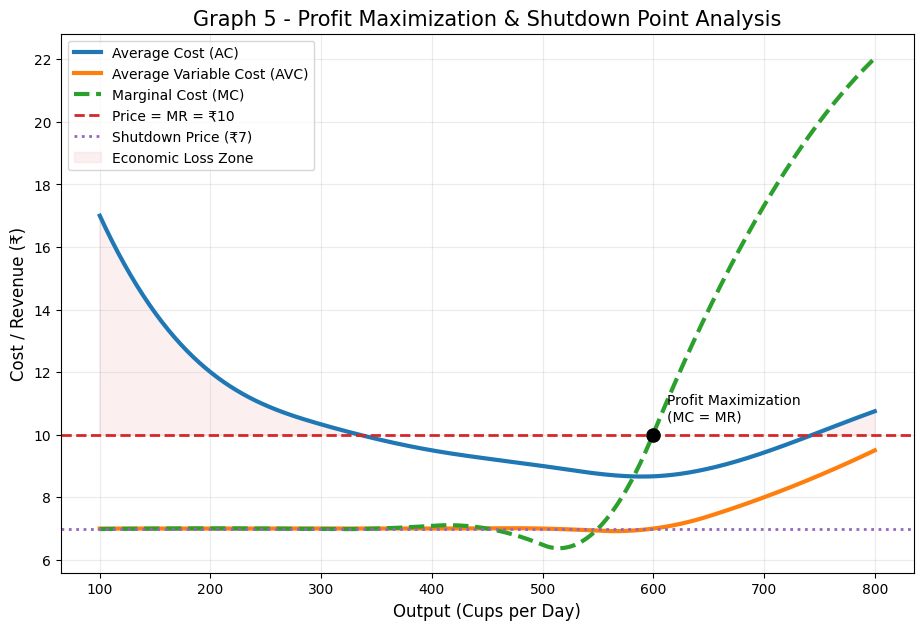

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# -----------------------------
# Data from your table
# -----------------------------

Q = np.array([100, 200, 300, 400, 500, 600, 700, 800])
AC = np.array([17, 12, 10.33, 9.5, 9, 8.67, 9.43, 10.75])
AVC = np.array([7, 7, 7, 7, 7, 7, 8, 9.5])
TC = np.array([1700, 2400, 3100, 3800, 4500, 5200, 6600, 8600])

price = 10

# Marginal Cost
MC = np.diff(TC) / np.diff(Q)
Q_mc = (Q[:-1] + Q[1:]) / 2

# Smooth curves
Q_smooth = np.linspace(Q.min(), Q.max(), 500)

ac_spline = make_interp_spline(Q, AC, k=3)
avc_spline = make_interp_spline(Q, AVC, k=2)
mc_spline = make_interp_spline(Q_mc, MC, k=2)

AC_smooth = ac_spline(Q_smooth)
AVC_smooth = avc_spline(Q_smooth)
MC_smooth = mc_spline(Q_smooth)

# Profit Maximization (MC = MR)
profit_Q = 600
profit_price = price

# Shutdown price
shutdown_price = 7

# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(11,7))

# Cost Curves
plt.plot(Q_smooth, AC_smooth, color="#1f77b4", linewidth=3, label="Average Cost (AC)")
plt.plot(Q_smooth, AVC_smooth, color="#ff7f0e", linewidth=3, label="Average Variable Cost (AVC)")
plt.plot(Q_smooth, MC_smooth, color="#2ca02c", linestyle="--", linewidth=3, label="Marginal Cost (MC)")

# Price / MR line
plt.axhline(price, color="#d62728", linestyle="--", linewidth=2, label="Price = MR = ₹10")

# Shutdown Line
plt.axhline(shutdown_price, color="#9467bd", linestyle=":", linewidth=2, label="Shutdown Price (₹7)")

# Profit Maximization Point
plt.scatter(profit_Q, price, color="black", s=90, zorder=5)
plt.annotate("Profit Maximization\n(MC = MR)",
             (profit_Q, price),
             textcoords="offset points",
             xytext=(10,10),
             fontsize=10)

# Economic Loss Zone shading
plt.fill_between(Q_smooth, AC_smooth, price,
                 where=(AC_smooth > price),
                 color="#f8d7da",
                 alpha=0.4,
                 label="Economic Loss Zone")

# Formatting
plt.title("Graph 5 - Profit Maximization & Shutdown Point Analysis", fontsize=15)
plt.xlabel("Output (Cups per Day)", fontsize=12)
plt.ylabel("Cost / Revenue (₹)", fontsize=12)

plt.legend(fontsize=10)
plt.grid(alpha=0.25)

plt.savefig("Graph5_Profit_Maximization_Shutdown_300DPI.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

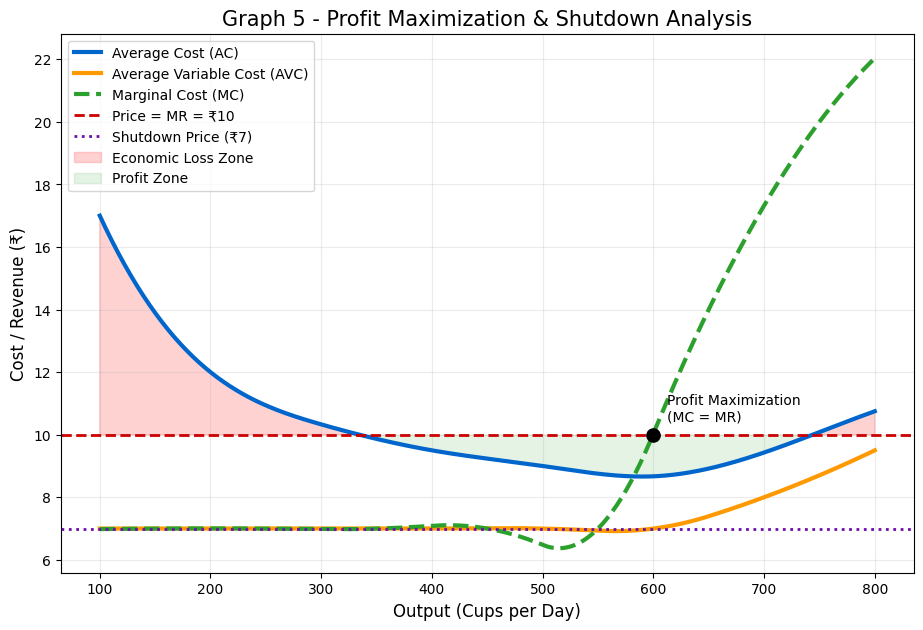

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# -----------------------------
# Your Original Data
# -----------------------------

Q = np.array([100, 200, 300, 400, 500, 600, 700, 800])
AC = np.array([17, 12, 10.33, 9.5, 9, 8.67, 9.43, 10.75])
AVC = np.array([7, 7, 7, 7, 7, 7, 8, 9.5])
TC = np.array([1700, 2400, 3100, 3800, 4500, 5200, 6600, 8600])

price = 10

# Marginal Cost
MC = np.diff(TC) / np.diff(Q)
Q_mc = (Q[:-1] + Q[1:]) / 2

# Smooth Curves
Q_smooth = np.linspace(Q.min(), Q.max(), 500)

ac_spline = make_interp_spline(Q, AC, k=3)
avc_spline = make_interp_spline(Q, AVC, k=2)
mc_spline = make_interp_spline(Q_mc, MC, k=2)

AC_smooth = ac_spline(Q_smooth)
AVC_smooth = avc_spline(Q_smooth)
MC_smooth = mc_spline(Q_smooth)

# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(11,7))

# Curves
plt.plot(Q_smooth, AC_smooth, color="#0066cc", linewidth=3, label="Average Cost (AC)")
plt.plot(Q_smooth, AVC_smooth, color="#ff9900", linewidth=3, label="Average Variable Cost (AVC)")
plt.plot(Q_smooth, MC_smooth, color="#2ca02c", linestyle="--", linewidth=3, label="Marginal Cost (MC)")

# Price line
plt.axhline(price, color="#cc0000", linestyle="--", linewidth=2, label="Price = MR = ₹10")

# Shutdown line
plt.axhline(7, color="#6a0dad", linestyle=":", linewidth=2, label="Shutdown Price (₹7)")

# -----------------------------
# Economic Loss Zone (Improved Colour)
# -----------------------------
plt.fill_between(Q_smooth, AC_smooth, price,
                 where=(AC_smooth > price),
                 color="#ff4d4d",   # strong but clean red
                 alpha=0.25,
                 label="Economic Loss Zone")

# Profit Zone (Optional Highlight)
plt.fill_between(Q_smooth, price, AC_smooth,
                 where=(AC_smooth < price),
                 color="#4caf50",
                 alpha=0.15,
                 label="Profit Zone")

# Profit Maximization Point
plt.scatter(600, price, color="black", s=90, zorder=5)
plt.annotate("Profit Maximization\n(MC = MR)",
             (600, price),
             textcoords="offset points",
             xytext=(10,10),
             fontsize=10)

# Formatting
plt.title("Graph 5 - Profit Maximization & Shutdown Analysis", fontsize=15)
plt.xlabel("Output (Cups per Day)", fontsize=12)
plt.ylabel("Cost / Revenue (₹)", fontsize=12)

plt.legend(fontsize=10)
plt.grid(alpha=0.25)



plt.savefig("Premium_Profit_Max_Shutdown_300DPI.png",
            dpi=300,
            bbox_inches='tight')

plt.show()